In [27]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

In [23]:
all_data = pd.read_csv("combined.csv")

agg_30 = pd.read_csv("aggregated_30m_year.csv")
agg_100 = pd.read_csv("aggregated_100m_year.csv")
agg_500 = pd.read_csv("aggregated_500m_noyear.csv")
agg_1000 = pd.read_csv("aggregated_1000m_year.csv")
agg_5000 = pd.read_csv("aggregated_5000m_year.csv")
agg_10000 = pd.read_csv("aggregated_10000m_noyear.csv")

dfs = [
    ("30m", agg_30),
    ("100m", agg_100),
    ("500m", agg_500),
    ("1000m", agg_1000),
    ("5000m", agg_5000),
    ("10000m", agg_10000),
]

/var/folders/dz/1ccfqg_n5mg3fsrt8rwm7fd80000gn/T/ipykernel_4317/2495021541.py:1: DtypeWarning: Columns (5,12,13,18,20,21,28,29,31,33,34,35,36,37,38,39,43,45) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data = pd.read_csv("combined.csv")


In [24]:
print("Full dataset:", len(all_data), "points")
for df in dfs:
    name, data = df
    print(f"Dataset at {name} aggregation:", len(data), "points")

Full dataset: 251774 points
Dataset at 30m aggregation: 10355 points
Dataset at 100m aggregation: 8196 points
Dataset at 500m aggregation: 4399 points
Dataset at 1000m aggregation: 3249 points
Dataset at 5000m aggregation: 1531 points
Dataset at 10000m aggregation: 878 points


In [30]:
# get min and max latitude across all datasets
min_lat = min(
    all_data["lat"].min(),
    agg_30["lat"].min(),
    agg_100["lat"].min(),
    agg_500["lat"].min(),
    agg_1000["lat"].min(),
    agg_5000["lat"].min(),
    agg_10000["lat"].min(),
)
max_lat = max(
    all_data["lat"].max(),
    agg_30["lat"].max(),
    agg_100["lat"].max(),
    agg_500["lat"].max(),
    agg_1000["lat"].max(),
    agg_5000["lat"].max(),
    agg_10000["lat"].max(),
)

print("Latitude range across all datasets:", min_lat, "to", max_lat)

Latitude range across all datasets: 0.0 to 83.09


In [25]:
# use lat and lon columns to turn into GDFs
all_data_gdf = gpd.GeoDataFrame(
    all_data,
    geometry=gpd.points_from_xy(all_data.lon, all_data.lat),
    crs="EPSG:4326",
)

gdfs = []

for df in dfs:
    name, data = df
    gdf = gpd.GeoDataFrame(
        data,
        geometry=gpd.points_from_xy(data.lon, data.lat),
        crs="EPSG:4326",
    )
    gdfs.append((name, gdf))

countries = gpd.read_file(
    "ne_50m_admin_0_countries_lakes/ne_50m_admin_0_countries_lakes.shp"
)

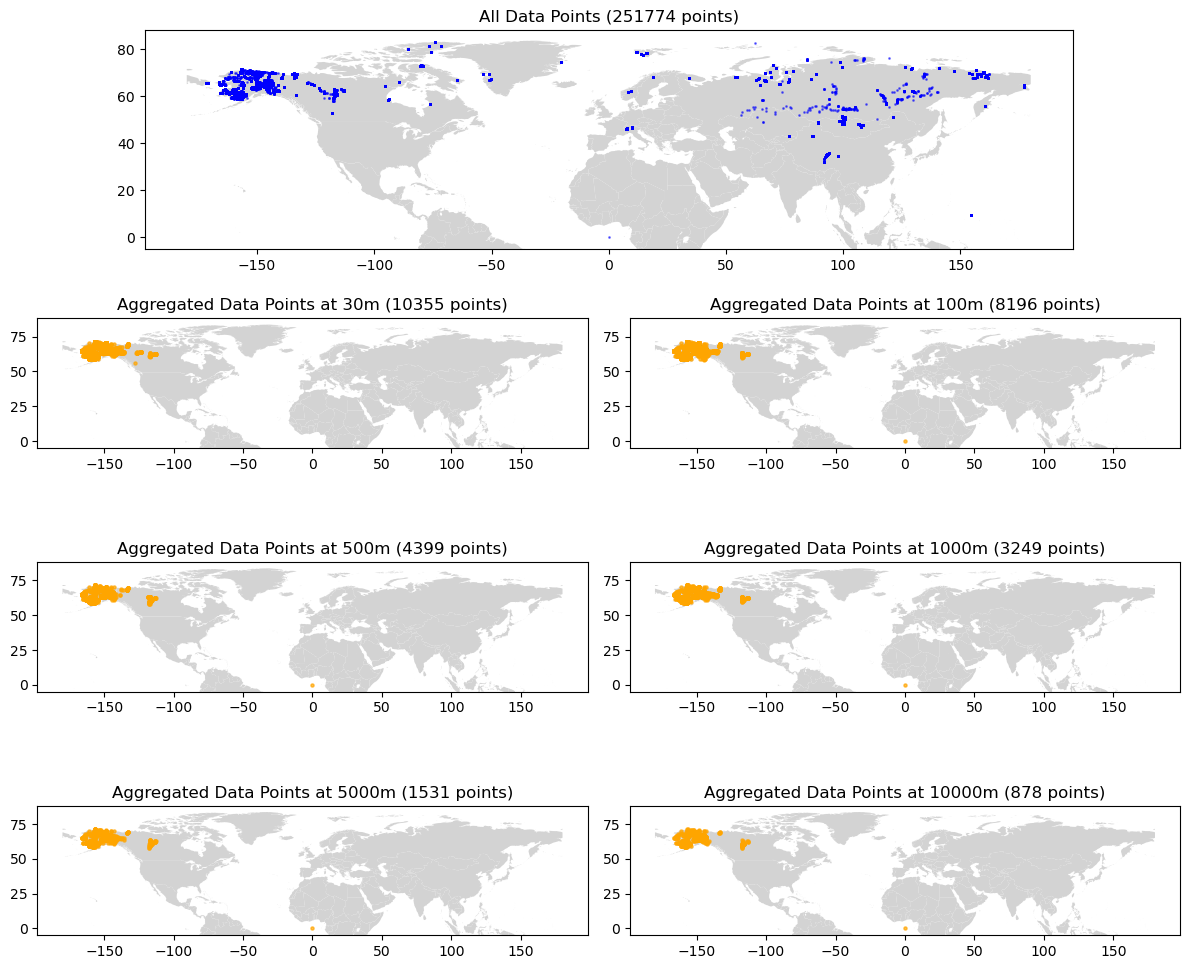

In [36]:
# create a grid of 2 cols 4 rows
# plot full dataset across entire rop row
# plot individual datasets in remaining rows

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(nrows=4, ncols=2, figure=fig)

# all data across top row
ax_span = fig.add_subplot(gs[0, :])
all_data_gdf.plot(
    ax=ax_span, color="blue", markersize=1, alpha=0.5, label="All Data Points", zorder=1
)
countries.plot(ax=ax_span, color="lightgray", zorder=0)
ax_span.set_title(f"All Data Points ({len(all_data_gdf)} points)")
ax_span.set_ylim(min_lat - 5, max_lat + 5)


# individual datasets in remaining subplots
for i, (name, gdf) in enumerate(gdfs):

    row = (i // 2) + 1
    col = i % 2

    ax = fig.add_subplot(gs[row, col])
    gdf.plot(
        ax=ax,
        color="orange",
        markersize=5,
        alpha=0.7,
        label=f"{name} Aggregated Points",
    )
    countries.plot(ax=ax, color="lightgray", zorder=0)
    ax.set_ylim(min_lat - 5, max_lat + 5)
    ax.set_title(f"Aggregated Data Points at {name} ({len(gdf)} points)")
plt.tight_layout()

Text(0.5, 1.0, 'Aggregated Data Points at 30m (10355 points)')

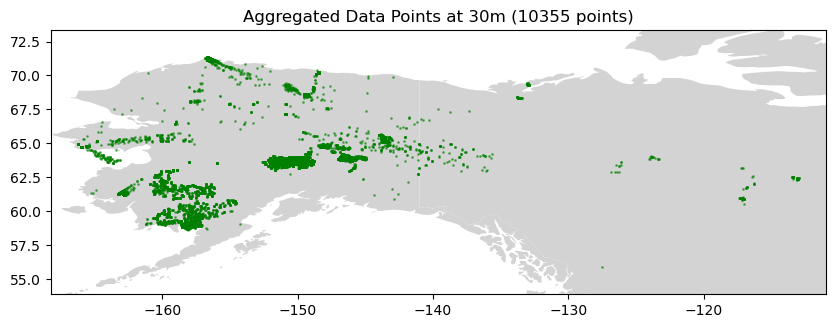

In [43]:
# plot just the 30m aggregated data

fig_30m = plt.figure(figsize=(10, 8))
ax_30m = fig_30m.add_subplot(1, 1, 1)

gdfs[0][1].plot(
    ax=ax_30m,
    color="green",
    markersize=1,
    alpha=0.5,
)

countries.plot(ax=ax_30m, color="lightgray", zorder=0)

min_lat_30m = gdfs[0][1]["lat"].min()
max_lat_30m = gdfs[0][1]["lat"].max()

min_lon_30m = gdfs[0][1]["lon"].min()
max_lon_30m = gdfs[0][1]["lon"].max()

ax_30m.set_ylim(min_lat_30m - 2, max_lat_30m + 2)
ax_30m.set_xlim(min_lon_30m - 2, max_lon_30m + 2)

ax_30m.set_title(f"Aggregated Data Points at {gdfs[0][0]} ({len(gdfs[0][1])} points)")

In [44]:
gdfs[0][1]

,lat,lon,date,n_grouped,pf_observed,pf_depth,obs_depth,obs_limit,source,transect_point,org_thick,rock,Soil Type,rocky/silty,Wildfire,Widlfire date/name,Burn Year,Canopy and Surface,geometry
0,63.145358,-117.259435,2019-08-15,1,0,NaN,NaN,NaN,Bonaventure_Whati,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.25944 63.14536)
1,63.160782,-117.162049,2019-08-15,3,1,NaN,NaN,NaN,Bonaventure_Whati,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.16205 63.16078)
2,63.165621,-117.145012,2019-08-15,3,1,NaN,NaN,NaN,Bonaventure_Whati,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.14501 63.16562)
3,65.489704,-142.047729,2017-05-29,4,1,75.0,75.000000,132.0,Minsley_2017,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-142.04773 65.4897)
4,65.489970,-142.047507,2017-05-29,4,1,131.5,128.666667,132.0,Minsley_2017,NaN,9.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-142.04751 65.48997)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10350,69.349313,-133.039300,2017-08-22,1,1,44.4,44.400000,100.0,Zhang_2019,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-133.0393 69.34931)
10351,69.323750,-133.028320,2017-08-22,1,1,48.2,48.200000,100.0,Zhang_2019,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-133.02832 69.32375)
10352,69.309959,-132.994360,2017-08-22,1,1,31.7,31.700000,100.0,Zhang_2019,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-132.99436 69.30996)
10353,69.311748,-132.998870,2017-08-22,1,1,48.7,48.700000,100.0,Zhang_2019,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-132.99887 69.31175)
